In [2]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (8, 4)
from scipy.io.wavfile import read
from scipy import signal
from IPython.display import Audio
import librosa
from librosa import feature, frames_to_time, autocorrelate, clicks, display

## Tempo Estimation

The beat (or pulse) of a musical piece is a *periodic* sequence of events or impulses. By examining the periodic structure of the impluses, we can try to estimate what one period is (the distance of a beat), which will allow us to guess the tempo. In tempo estimation, we are trying to figure out the regularity between events (onsets).

We are going to cover two simple approaches for global tempo estimation: autocorrelation and inter onset interval. Both rely on our ability to detect onsets.

We are going to try detecting the tempo of a drum sample. When I tapped the tempo, I got around 110 bpm.

In [35]:
(fs, x) = read('../audio/80spopDrums.wav')
x = x/np.abs(x.max())
Audio(x, rate=fs)

We'll start by defining our novelty function.

In [5]:
hop_length = 512 # 50% overlap
frame_length = 1024

In [6]:
rmse = librosa.feature.rms(y = x, frame_length=frame_length, hop_length=hop_length)
rmse_diff = np.diff(rmse[0])
novelty = np.concatenate((rmse_diff, np.array([0])))
novelty[novelty < 0] = 0

In [7]:
len(rmse[0])

752

### Autocorrelation

We have learned about correlation. Autocorrelation is used to find how similar a signal, or function, is *to itself* at a certain time difference (or shifted position), which is referred to as *lag*.

For example, let's say I have the following sequence:

In [145]:
vals = np.array([4,1,3,1,4,1.5,2.5,0.2,3.5,1,2,1.5])

Let's make a plot to see it better:

<StemContainer object of 3 artists>

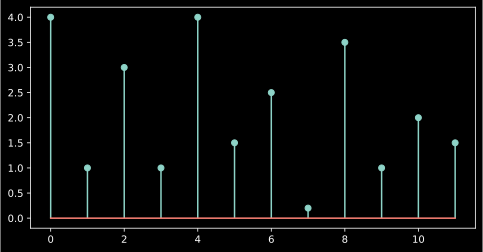

In [146]:
plt.stem(vals)

An autocorrelation will compare this original array to every possible shifted version of itself.

[None]

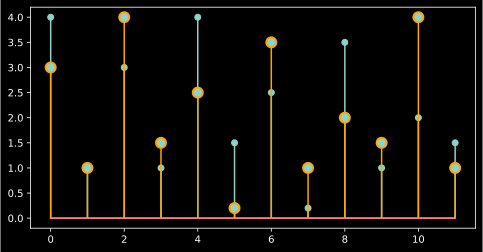

In [147]:
a = np.roll(vals, -1)
b = np.roll(vals, -2)
c = np.roll(vals, -3)
d = np.roll(vals, -4)

plt.stem(vals)
(markers, stemlines, baseline) = plt.stem(b)
plt.setp(markers, markersize=10, markeredgecolor="orange", markeredgewidth=2)
plt.setp(stemlines, color='orange')


In [148]:
np.corrcoef(vals, a)

array([[ 1.        , -0.74337748],
       [-0.74337748,  1.        ]])

The autocorrelation tells us when a signal is most like itself when shifted forward in time. 

The autocorrelation at lag=0 will always be 1 (if normalized) and the autocorrelation result will be periodic around the length of the signal.

Rather than manually shifting and calculating the correlation, we will use `librosa.autocorrelate(x)`.


`librosa.autocorrelate(x)` computes the **non-circular autocorrelation** of the signal. Under the hood, it behaves similarly to:

`np.correlate(x, x, mode='full')[len(x)-1:]`

#### Mathematical Definition
The autocorrelation at lag $\tau$ is defined as:
$$
R(\tau) = \sum_{t=0}^{N - \tau - 1} x[t] \cdot x[t + \tau]
$$

Where:

$x[t]$ is the signal value at time $t$

$N$ is the total number of samples

$\tau$ is the lag (in samples)

This gives us a measure of how similar the signal is to itself when shifted by $\tau$ steps.

Notice this is just like as our DFT process, except we are multiplying and summing not with a basis function (sinusoid) but a shifted version of the input itself.

Whereas `np.roll()` uses a rotating vector (i.e., takes the values from the end and places them at the beginning) in audio signal autocorrelation we don't want to reorganize the signal values, so the method instead is to remove the values that you have shifted over, and replace them with zeros.


### Using autocorrelation for tempo estimation

Let's apply autocorrelation to our novelty function (onset_envelope) to look for periodicities in the distance between spikes.

In [8]:
ac = librosa.autocorrelate(novelty)
ac = ac / ac.max()

Text(0.5, 0, 'Time lag (in frames)')

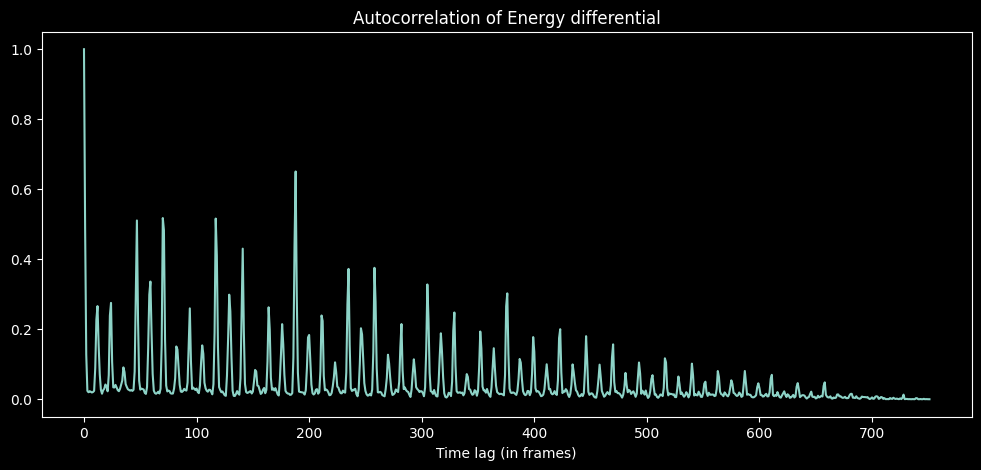

In [9]:
plt.figure(figsize=(12,5))
plt.plot(ac)
plt.title('Autocorrelation of Energy differential')
plt.xlabel('Time lag (in frames)')

Text(0.5, 1.0, 'Autocorrelation of Energy Differential')

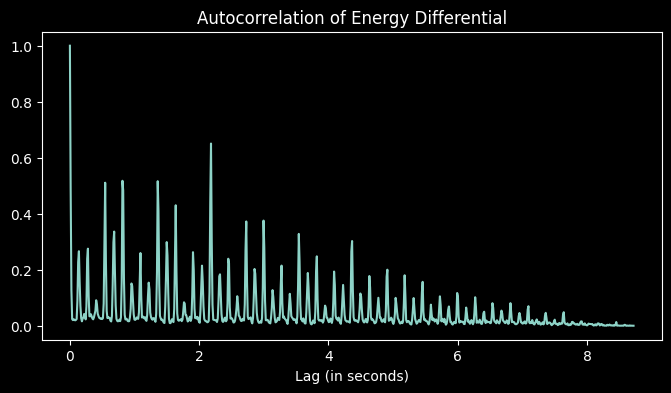

In [10]:
lags = np.arange(len(ac))
plt.plot(lags * hop_length / fs, ac)
plt.xlabel("Lag (in seconds)")
plt.title("Autocorrelation of Energy Differential")

The autocorrelation tells us visually that at lag time 0, we are most similar as we said above. Then somewhere around 2.1 second and around the 0.5 and 0.6 second lag are our next most similar.

In [11]:
ac.argmax()

0

In [12]:
ac[1:].argmax()

187

Our next max (beyond 0) is at index 187. We can convert this to a time value with 

lag_time = lag * hop_length / fs

In [13]:
187 * 512 / fs

2.1710657596371883

This doesn't tell us our tempo yet. Remember for tempo, we are interested in the relationship between onsets. So, we are going to compare across the autocorrelation function peaks to find some periodicity.

Based on our visual analysis, we'll take all lag times that have a correlation greater than 0.3

In [22]:
points = np.where(ac > 0.3) # ignore zero and one indices
points

(array([  0,   1,  47,  59,  70,  71, 117, 118, 141, 187, 188, 235, 258,
        305, 376]),)

We'll convert those to time (rather than index) as well.

In [23]:
points = np.array(points)
t_inc = hop_length * points / fs
#ignore first two values (zero and one)
t_inc[0][2:]

array([0.54566893, 0.68498866, 0.81269841, 0.82430839, 1.35836735,
       1.36997732, 1.6370068 , 2.17106576, 2.18267574, 2.72834467,
       2.99537415, 3.54104308, 4.36535147])

Now, we find the differences between the values. This will show us some kind of regularity between the correlated lag times. 

Each of these highly correlated points could represent beats, downbeats, eighth note rhythms, etc,

In [24]:
#calculate the differences between the values
ts = t_inc[0][2:]

durs = ts[1:] - ts[:-1]
durs = np.round(durs, 3) # round to 3 decimal places
durs

array([0.139, 0.128, 0.012, 0.534, 0.012, 0.267, 0.534, 0.012, 0.546,
       0.267, 0.546, 0.824])

We now see some time distance repetition between the ACF results. The most common time distances will give us our estimated tempo

In [25]:
from collections import Counter

# Get the top N most common elements, let's say top 3 for this example
num_counts = Counter(durs)
top_n = num_counts.most_common(3)

print(top_n)


[(0.012, 3), (0.534, 2), (0.267, 2)]


The tempo in beats per minute (BPM) is calculated as:

$$
\text{Tempo (BPM)} = \frac{60}{\text{Seconds per Beat}}
$$

So if the periodicity we detect is approximately 0.534 seconds:

$$
\frac{60}{0.534} \approx 112.36 \text{ BPM}
$$

In [26]:
tempa = 60 / .267
tempb = 60 / .012
tempc = 60 / .534

print( tempa, tempb, tempc)

224.7191011235955 5000.0 112.35955056179775


Tempo is reasonably between 40-300 bpm, so given that we can estimate our bpm is 224 (or 112).

Think about the relationship between 224 and 112. We'll come back to that in a moment.


### Inter-Onset Intervals for Tempo Estimation

Another way to perform tempo estimation is simply by looking at the distance between our detected onsets. 

From our novelty function, we need to apply peak picking and find onset times

In [209]:
frames = range(len(novelty))

# create time array for frame values (for vizualizing)
t = librosa.frames_to_time(frames, sr=fs, hop_length=hop_length)

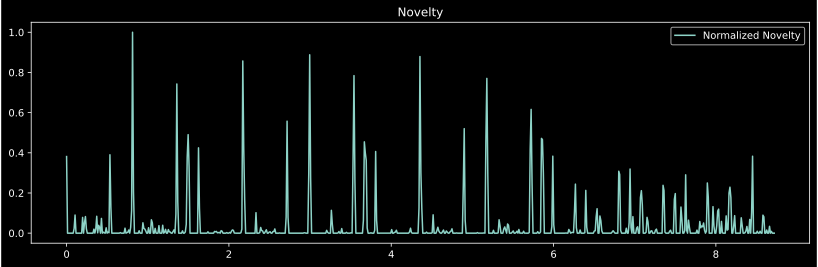

In [212]:
plt.figure(figsize=(14,4))
plt.plot(t, novelty/novelty.max(), label='Normalized Novelty')
plt.legend()
plt.title('Novelty')
plt.show()

Visually, let's go with 0.15 threshold. 

We can also check ourselves with the clicks function from librosa

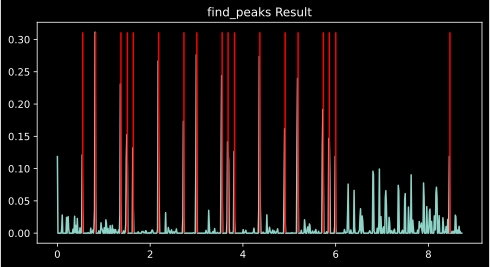

In [249]:
peaks, properties = signal.find_peaks(novelty, height=0.1)

peak_times = t[1:][peaks]

plt.plot(t, novelty)
plt.vlines(peak_times, 0, np.max(novelty), colors='r')
plt.title('find_peaks Result')
plt.show()

In [250]:
clicks = librosa.clicks(times=peak_times, sr=fs, hop_length=None)
clicks.resize(x.shape)
combn = clicks + x
Audio(combn, rate=fs)

Once we have our onsets, we can compute inter-onset-intervals. This is just the time distance between our detected onsets.

In [265]:
iois = np.diff(peak_times)
iois

array([0.27863946, 0.54566893, 0.13931973, 0.12770975, 0.54566893,
       0.54566893, 0.27863946, 0.54566893, 0.12770975, 0.13931973,
       0.54566893, 0.54566893, 0.27863946, 0.54566893, 0.12770975,
       0.13931973, 2.46131519])

Again, you'll notice there is repetition in our IOIs. Let's determine what time spacings are most common to estimate tempo.

In [252]:
num_counts = Counter(iois)
top_n = num_counts.most_common(3)

print(top_n)

[(0.5456689342403629, 3), (0.12770975056689338, 3), (0.13931972789115665, 2)]


Our most common are .546, 0.128, and 0.139 seconds.

We calculate tempo the same as we did for ACF.

In [262]:
tempo1 = 60 / 0.546
tempo2 = 60 / 0.128
tempo3 = 60 / .139

print(tempo1, tempo2, tempo3)

109.89010989010988 468.75 431.65467625899277


Here we get around 110 and around 469??

## Tempo Estimation Considerations 

### Doubling

Due to the metrical, periodic structure of music, we often get many tempo estimates back from our algorithm that are integer multiples of each other. This accounts for down beats, start of measures, quarter notes, eighth notes, and any other hierarchical patterns.

From "Intro to Audio Content Analysis" by Lerch, the best tempo detection systems have an accuracy of between 60-90%. But if you ignore doubling errors, they have about 90% accuracy. 

### Varying Tempo

The algorithms we've discussed cover global tempo and assume tempo does not change. However, tempos often change in music whether very slightly or by section. 

We can apply our tempo system iteratively across our file to come up with a better idea of the tempo changes over time. For real-time tempo tracking or beat tracking cases, systems will be even more adaptive. First, they will define an initial estimate (like we did above) then predict where the next beat will occur, take in the incoming data, compare, and update the current state. This allows variation in tempo over time

### Beat Histograms and Tempograms

When we calculated our autocorrelation and IOI periodicities above, we ran a count on the repeated occurrences.

In rhythmic analysis, we often view our results in a beat histogram or beat spectrum where the x-axis shows tempo in BPM and the y-axis shows beat strength. Rather than only selecting and counting a few possible bpms, a beat histogram is a way to visualize all tempo hypotheses at once and see which one is strongest.

Text(0.5, 1.0, 'Beat Histogram (Autocorrelation)')

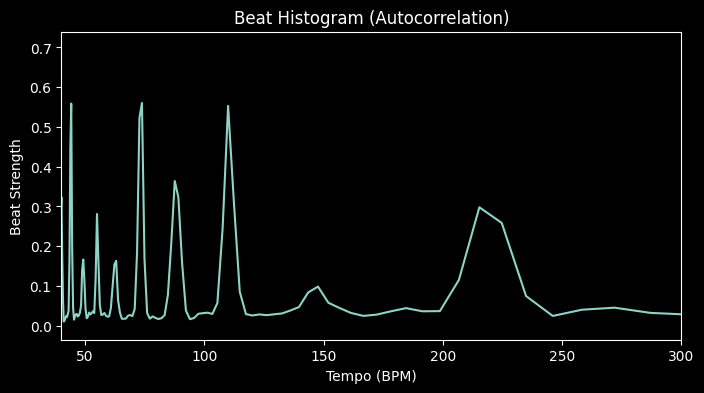

In [ ]:
ac = librosa.autocorrelate(novelty)
lags = np.arange(len(ac))
lag_times = lags * hop_length / fs
bpms = 60 / lag_times[1:]   # avoid divide by zero
strength = ac[1:]

plt.plot(bpms, strength)
plt.xlim(40, 300)
plt.xlabel("Tempo (BPM)")
plt.ylabel("Beat Strength")
plt.title("Beat Histogram (Autocorrelation)")

Similarly, we can show estimated tempo changes (and strengths) over time with a tempogram. Rather than being global or captured at one instance, the tempogram shows tempo over time kind of like a spectrogram. The x-axis represents time, the y-axis represents tempo (in BPM), and the color intensity represents the strength of that tempo at that moment.

Text(0.5, 1.0, 'Tempogram')

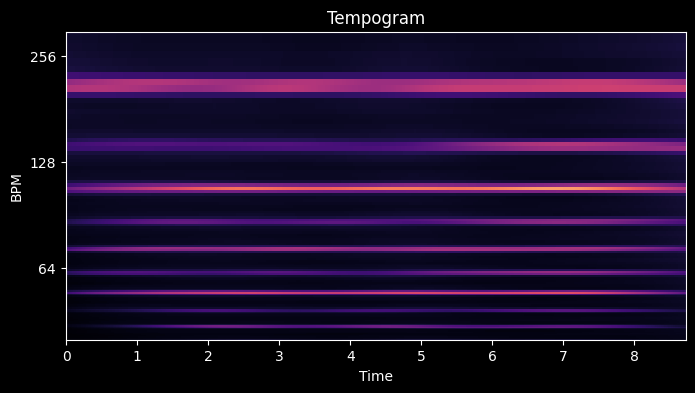

In [37]:
onset_env = librosa.onset.onset_strength(y=x, sr=fs, hop_length=hop_length)
tempogram = librosa.feature.tempogram(onset_envelope=onset_env, sr=fs, hop_length=hop_length)
librosa.display.specshow(tempogram, sr=fs, hop_length=hop_length, x_axis='time', y_axis='tempo', cmap='magma')
plt.ylim(40, 300)
plt.title("Tempogram")


Text(0.5, 1.0, 'Tempogram')

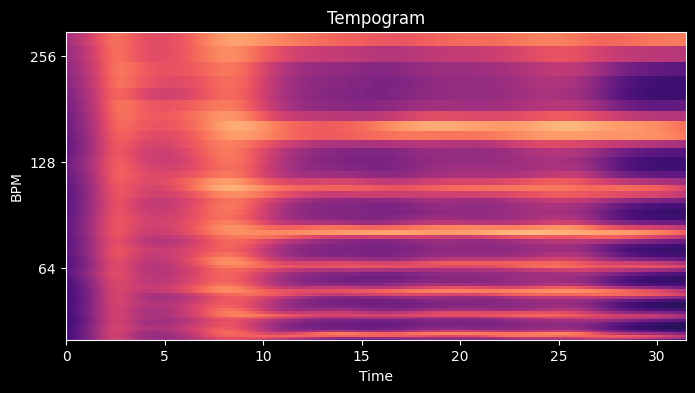

In [38]:
x, fs = librosa.load('../audio/TheBlackKeys_track4.wav')
onset_env = librosa.onset.onset_strength(y=x, sr=fs, hop_length=hop_length)
tempogram = librosa.feature.tempogram(onset_envelope=onset_env, sr=fs, hop_length=hop_length)
librosa.display.specshow(tempogram, sr=fs, hop_length=hop_length,
                         x_axis='time', y_axis='tempo', cmap='magma')
plt.ylim(40, 300)
plt.title("Tempogram")

### Other Uses of Autocorrelation in Music DSP

- **Pitch Detection**: Repeating waveforms (e.g., from sung vowels) can be tracked using autocorrelation to estimate pitch.
- **Meter Estimation**: Beyond tempo, we can use autocorrelation hierarchically to estimate larger structures, such as meters. This involves looking for subharmonics or harmonics in the autocorrelation peaks.
- **Loop Point Detection**: In audio looping (like in sampling or sound design), autocorrelation can help find natural looping points by identifying repeated signal patterns.
- **Periodicity-Based Segmentation**: Some rhythm or style classifiers use autocorrelation to segment time-series signals based on repeating patterns.


## Meter Estimation
With meter, our beats recur in patterns of stronger and weaker beats. This hierarchical structure can be detected by examining **the periodicity of the signal at multiple levels.**

#### Hierarchical Autocorrelation for Meter
To estimate meter, we can apply autocorrelation not just at the level of the beat (as we did for tempo) but also at sub-beats and higher-order periodicities (e.g., the measure). This involves looking for autocorrelation peaks at different time scales:

**Beat level:** The fundamental period we detected earlier with autocorrelation corresponds to the basic tempo of the piece.

**Sub-beat level:** To detect subdivisions of the beat (like eighth notes or sixteenth notes), we look for peaks at half or quarter the beat's period.

**Measure level:** We can further examine higher-order periodicities corresponding to measures, typically involving periods that are multiple times the beat.

For example: after detecting the beat period, we can check for harmonics of that period (i.e., periods that are integer multiples of the beat period) in the autocorrelation result. The presence of significant peaks at these multiple timescales indicates a strong meter structure.